In [1]:
%load_ext autoreload

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib import container
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
import tabulate 

import IPython

In [3]:
%autoreload 2

from util import *

In [4]:
sns.set_theme(style="whitegrid", rc={"axes.grid": False}, font_scale=1.1)

# Load Data

In [5]:
# CPI: https://www.minneapolisfed.org/about-us/monetary-policy/inflation-calculator/consumer-price-index-1913-
cpi_map = {
    2013: 233,
    2014: 236.7,
    2015: 237,
    2016: 240,
    2017: 245.1,
    2018: 251.1,
    2019: 255.7,
    2020: 258.8,
    2021: 271,
    2022: 292.7,
    2023: 304.7,
    2024: 313.7,
    2025: 322.3
}

In [6]:
final_spine_codes = [
    '22551', '22552', '22548', '63081', '63082', '22554', '22585', '22856', '22845', '22846', '22558', '22585', 
    '22630', '22632', '22600', '22590', '22595', '22614', '22840', '22612', '22842', '22843', '63020', '63035', 
    '63040', '63045', '63048', '63051', '63077', '23078', '23085', '63086', '63087', '63088', '63101', '63103', 
    '22556', '22585', '22851', '22845', '22846', '63046', '63048', '63055', '63057', '63064', '63066', '63085', 
    '63086', '63087', '22610', '66214', '22840', '22842', '22843', '22844', '63090', '63091', '22558', '22585', 
    '22857', '22862', '22845', '22846', '63030', '63047', '63035', '63042', '63044', '63048', '63012', '22630', 
    '22632', '22612', '22614', '22633', '22634', '22840', '22842', '22843', '22853', "22854", "22859", '22847',
    "63001", "63015", "63043", "63050", "63075", "63076", "63003", "63016", "63005", "63017", "63052", "63053",
    "62380", "22800", "22802", "22804", "22810", "22812", "22534", "22532", "22533"
]

final_neurovasc_codes = ["61624", "61626", "61645", "61635", "37215", "37216", "37236", "37237"]

# other codes
# 22849 - reinsertion due to device failure
# 75898 - diagnostic for neuroIR?

In [7]:
# 20260826 variant: ALL codes included, add-ons and all. Both exclusion lists are
# emptied so cpt_map keeps every code in cpt_spine / cpt_neurovasc.
# Original lists preserved below for reference.
#
# spine_addons = [
#     "22552", "63082", "22585", "22585", "22632", "22614", "63048", "63078", "63086", "63088", "63103", "22585",
#     "63048", "63066", "63086", "63091", "22585", "63044", "63048", "22632", "22614", "22634", "63035", "63043",
#     "63053", "63057", "63076", "63076", "22534"
# ]
# neurovasc_addons = ['37237', '61642', '61641']

spine_addons = []
neurovasc_addons = []


In [58]:
cpt_spine = {
    "instrumentation": [
        "22840", "22842", "22843", "22844", "22845", "22846", "22847", "22853", 
        "22854", "22859", "22849", "22851", "22856"
    ],
    "bone_grafting": [
        "20930", "20931", "20936", "20937", "20938", "20939"
    ],
    "decompression": [
        "63001", "63015", "63045", "63020", "63040", "63043", "63048", "63035", 
        "63050", "63051", "63075", "63076", "63081", "63082", "63003", "63016",
        "63046", "63085", "63086", "63087", "63005", "63017", "63047", "63030",
        "63042", "63044", "63052", "63053", "62380", "63090", "63091", "63012",
        "63055", "63056", "63057", "63064", "63066", "63077", "63078", "63088",
        "63101", "63102", "63103"
    ],
    "fusion": [
        "22800", "22802", "22804", "22808", "22810", "22812", "22585", "22614", "22534", 
        "22551", "22552", "22554", "22590", "22595", "22556", "22532", "22558",
        "22533", "22612", "22630", "22632", "22633", "22634", "22548", "22600",
        "22610"
    ],
}   

cpt_neurovasc = {
    'aneurysm_embo': ['61624', '61626'],
    # 75894 double-counts the CNS embolizations in aneurysm_embo; kept as its own category
    # here since this variant includes everything. 2013 is CNS-restricted by the filter below.
    # 'transcath_therapy': ['75894'],
    'thrombectomy': ['61645'],
    'stent': ['37215', '37216', '37236', '37237'],
    'intracranial_angioplasty': ['61635', '61630', '61640', '61641', '61642']
}

In [59]:
human_readable_names_spine = {
    'instrumentation': 'Instrumentation',
    'bone_grafting': 'Bone grafting',
    'decompression': 'Decompression',
    'fusion': 'Fusion'
}

human_readable_names_neurovasc = {
    'aneurysm_embo': 'Aneurysm embolization',
    'transcath_therapy': 'Transcatheter therapy',
    'thrombectomy': 'Thrombectomy',
    'stent': 'Neurovascular Stenting',
    'intracranial_angioplasty': 'Intracranial angioplasty'
}

In [60]:
for name in cpt_spine:
    print(name)
    print(", ".join([code for code in cpt_spine[name] if code not in spine_addons]))

instrumentation
22840, 22842, 22843, 22844, 22845, 22846, 22847, 22853, 22854, 22859, 22849, 22851, 22856
bone_grafting
20930, 20931, 20936, 20937, 20938, 20939
decompression
63001, 63015, 63045, 63020, 63040, 63043, 63048, 63035, 63050, 63051, 63075, 63076, 63081, 63082, 63003, 63016, 63046, 63085, 63086, 63087, 63005, 63017, 63047, 63030, 63042, 63044, 63052, 63053, 62380, 63090, 63091, 63012, 63055, 63056, 63057, 63064, 63066, 63077, 63078, 63088, 63101, 63102, 63103
fusion
22800, 22802, 22804, 22808, 22810, 22812, 22585, 22614, 22534, 22551, 22552, 22554, 22590, 22595, 22556, 22532, 22558, 22533, 22612, 22630, 22632, 22633, 22634, 22548, 22600, 22610


In [61]:
for name in cpt_neurovasc:
    print(name)
    print(", ".join([code for code in cpt_neurovasc[name] if code not in neurovasc_addons]))

aneurysm_embo
61624, 61626
thrombectomy
61645
stent
37215, 37216, 37236, 37237
intracranial_angioplasty
61635, 61630, 61640, 61641, 61642


In [62]:
cpt_map = {}

for category, codes in cpt_spine.items():
    for code in codes:
        if code not in spine_addons:
            cpt_map[int(code)] = category

for category, codes in cpt_neurovasc.items():
    for code in codes:
        if code not in neurovasc_addons:
            cpt_map[int(code)] = category

In [63]:
current_dir = os.getcwd()

In [64]:
spine_data = pd.read_csv(os.path.join(current_dir, "processed-data", "spine_cpt_processed_with_ortho.csv"))
neurovasc_data = pd.read_csv(os.path.join(current_dir, "processed-data", "neurovasc_cpt_processed_all_providers.csv"))

In [65]:
# 75894 was a generic embolization S&I code before the 2014 CPT bundling into 37241-37244,
# so 2013 mixes CNS embolization with non-CNS embolization billed by interventional radiology.
# Restrict 2013 75894 to providers who also billed 61624/61626 that year, putting it on the
# same footing as 2014 onward.
cns_npis_2013 = set(
    neurovasc_data.loc[
        (neurovasc_data['year'] == 2013)
        & (neurovasc_data['HCPCS_Cd'].isin([61624, 61626])),
        'Rndrng_NPI'
    ]
)

is_2013_75894 = (neurovasc_data['year'] == 2013) & (neurovasc_data['HCPCS_Cd'] == 75894)
drop_2013_75894 = is_2013_75894 & ~neurovasc_data['Rndrng_NPI'].isin(cns_npis_2013)

print(
    f"2013 75894: dropping {drop_2013_75894.sum()} of {is_2013_75894.sum()} rows "
    f"({neurovasc_data.loc[drop_2013_75894, 'Tot_Srvcs'].sum():.0f} of "
    f"{neurovasc_data.loc[is_2013_75894, 'Tot_Srvcs'].sum():.0f} services) "
    "from providers with no CNS embolization that year"
)

neurovasc_data = neurovasc_data[~drop_2013_75894].reset_index(drop=True)


2013 75894: dropping 216 of 297 rows (5196 of 6920 services) from providers with no CNS embolization that year


# Set Up Dataframes

In [66]:
for df in [spine_data, neurovasc_data]:
    df['CPI'] = df['year'].map(cpi_map).fillna(0)
    
    # Adjusted amounts
    df['Avg_Mdcr_Stdzd_Amt_adj'] = df['Avg_Mdcr_Stdzd_Amt'] / df['CPI'] * cpi_map[2023]
    df['Avg_Mdcr_Pymt_Amt_adj'] = df['Avg_Mdcr_Pymt_Amt'] / df['CPI'] * cpi_map[2023]

    # Raw amounts summed over services per provider
    df['Tot_Srvcs_Spend'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt'] 
    df['Tot_Pymt'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt'] 

    # Raw amounts summed over services per provider, adjusted
    df['Tot_Srvcs_Spend_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt_adj'] 
    df['Tot_Pymt_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt_adj'] 

# Select only necessary comlumns
spine_data = spine_data[[
    "HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", 
    "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj",
    "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"
]]
neurovasc_data = neurovasc_data[[
    "HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", 
    "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj",
    "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year", 'Rndrng_Prvdr_Type'
]]

for data in [spine_data, neurovasc_data]:
    data['procedure'] = data['HCPCS_Cd'].map(cpt_map)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_44003/133832597.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['procedure'] = data['HCPCS_Cd'].map(cpt_map)


In [67]:
groupby_key = 'procedure'
specialty_name = ["Spine", "Neurovascular"]

# Group by procedure and year, and summarize
util_2023_2013_adj_spine = (
    spine_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
    )
)

util_2023_2013_adj_neurovasc = (
    neurovasc_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
)

# Get CIs for Avg_Mdcr_Stdzd_Amt
ci_spine = bootstrap_agg_price_ci(spine_data, groupby_key)
util_2023_2013_adj_spine = util_2023_2013_adj_spine.merge(ci_spine, on=[groupby_key, 'year'], how='left')

ci_neurovasc = bootstrap_agg_price_ci(neurovasc_data, groupby_key)
util_2023_2013_adj_neurovasc = util_2023_2013_adj_neurovasc.merge(ci_neurovasc, on=[groupby_key, 'year'], how='left')

In [68]:
for df in [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]:
    df['Agg_Price_per_service_adj'] = df['Sum_Spend_adj'] / df['Sum_Utilization']

In [69]:
util_2023_2013_adj_spine['procedure_human_readable'] = util_2023_2013_adj_spine['procedure'].map(human_readable_names_spine)
util_2023_2013_adj_neurovasc['procedure_human_readable']  = util_2023_2013_adj_neurovasc['procedure'].map(human_readable_names_neurovasc)

In [70]:
# util_2023_2013_adj_spine = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] >= 2016].reset_index(drop=True)
# util_2023_2013_adj_neurovasc = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] >= 2016].reset_index(drop=True)

# Utilization

In [71]:
util_2023_2013_adj_spine['Sum_Utilization'].sum(), util_2023_2013_adj_neurovasc['Sum_Utilization'].sum()

(7567415.0, 72673.0)

In [72]:
spine_util_2013 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2013]['Sum_Utilization'].sum()
spine_util_2023 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2023]['Sum_Utilization'].sum()

(spine_util_2023 - spine_util_2013) / spine_util_2013 * 100

-3.8237138792430896

In [73]:
neurovasc_util_2013 = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] == 2013]['Sum_Utilization'].sum()
neurovasc_util_2023 = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] == 2023]['Sum_Utilization'].sum()

(neurovasc_util_2023 - neurovasc_util_2013) / neurovasc_util_2013 * 100

463.73951652688703

In [74]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Utilization',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [75]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -0.175 | weighted AAGR: -0.025

    procedure           AAGR_%
--  ---------------  ---------
 0  bone_grafting    -0.700399
 1  decompression    -2.83285
 2  fusion            1.8998
 3  instrumentation   0.934742

Neurovascular | unweighted AAGR: 16.446 | weighted AAGR: 17.626

    procedure                   AAGR_%
--  ------------------------  --------
 0  aneurysm_embo              12.9541
 1  intracranial_angioplasty   18.2454
 2  stent                      13.1402
 3  thrombectomy               21.4443



In [76]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovascular'][0]['AAGR_%'])

Ttest_indResult(statistic=-7.184715275829352, pvalue=0.0003675490546209887)

In [77]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    cagrs[specialty_name[i]] = compute_cagr(
        df,
        col='Sum_Utilization',
        groupby_key='procedure',
        years=[2013, 2023]
    )

In [78]:
for specialty, cagr in cagrs.items():
    print(specialty)
    print(tabulate.tabulate(cagr, headers=cagr.columns))
    print()

Spine
    procedure          CAGR_pct    effective_start_year    effective_end_year
--  ---------------  ----------  ----------------------  --------------------
 0  bone_grafting     -2.07968                     2013                  2023
 1  decompression     -3.11055                     2013                  2023
 2  fusion             1.63979                     2013                  2023
 3  instrumentation    0.625561                    2013                  2023

Neurovascular
    procedure                   CAGR_pct    effective_start_year    effective_end_year
--  ------------------------  ----------  ----------------------  --------------------
 0  aneurysm_embo               12.0338                     2013                  2023
 1  intracranial_angioplasty    -2.75075                    2015                  2023
 2  stent                        9.91314                    2013                  2023
 3  thrombectomy                18.236                      2016            

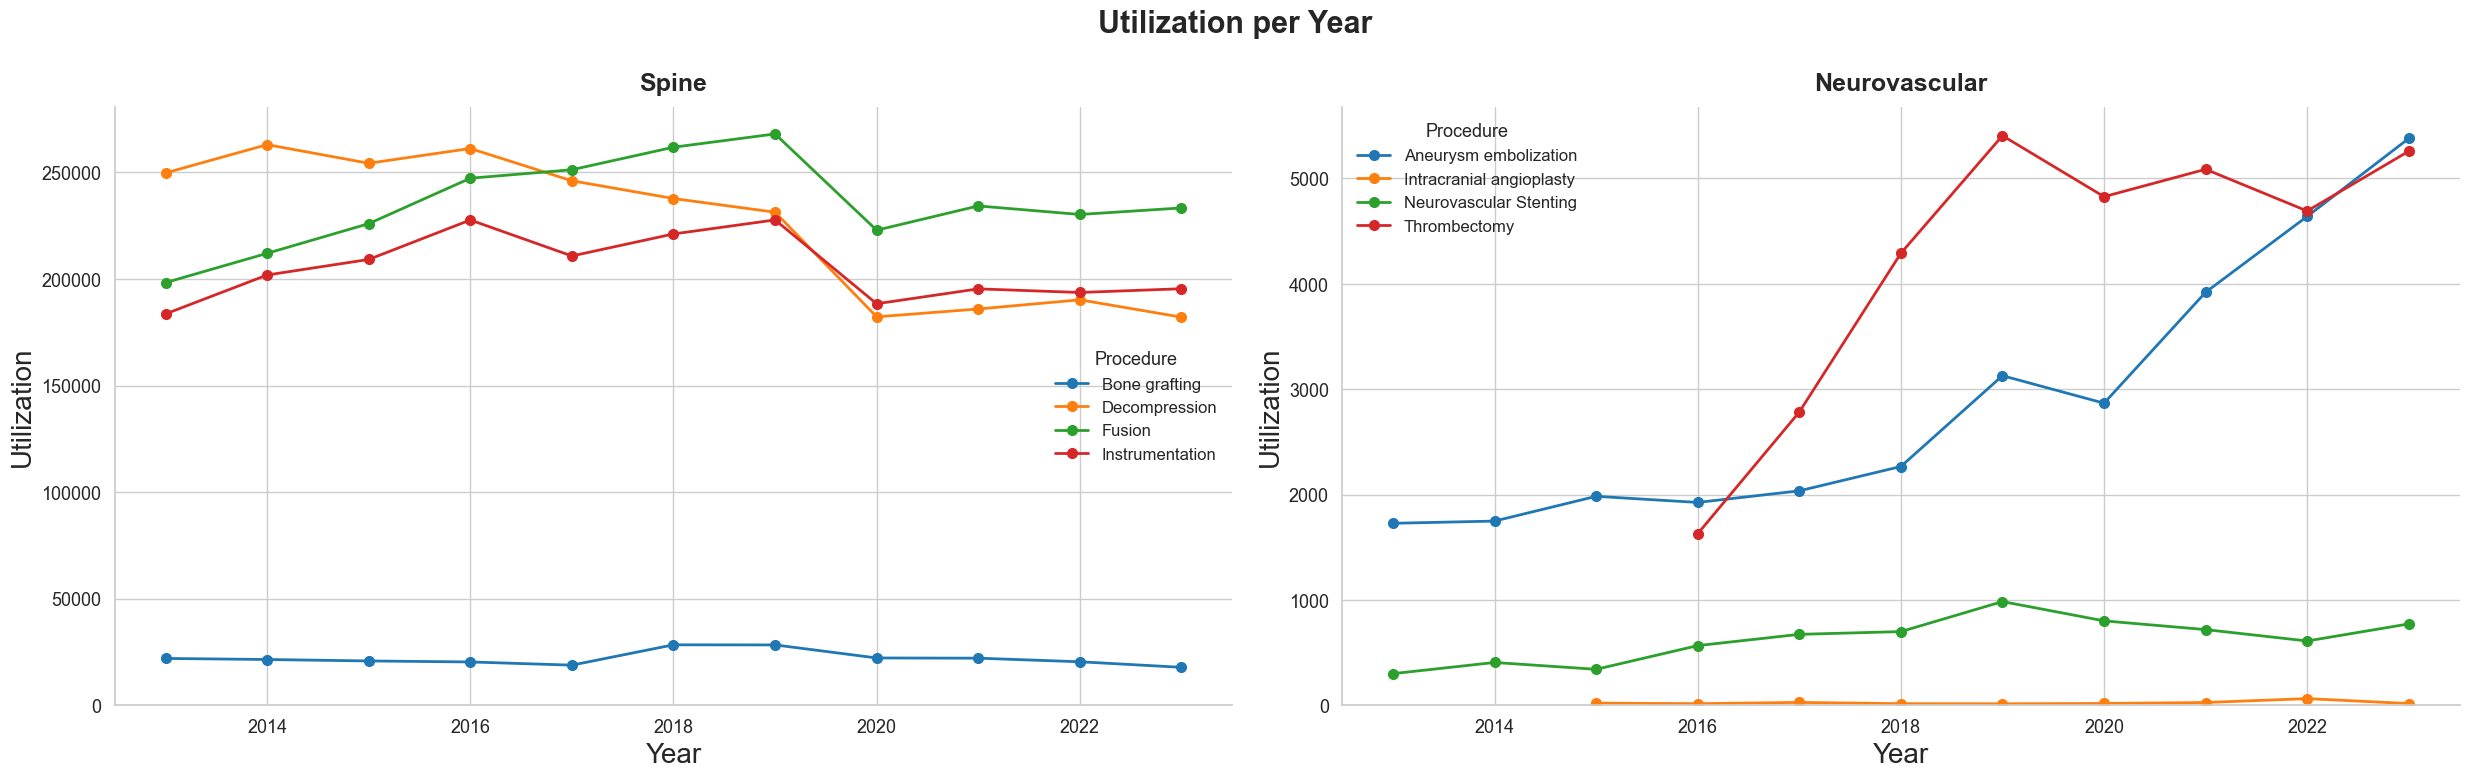

In [79]:
plot_by_specialty(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    y_col='Sum_Utilization',
    y_label='Utilization',
    figsize=(25, 8),
    title="Utilization per Year",
    legend_label_col='procedure_human_readable'
)

# Average Standardized Payment

In [80]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Avg_Price_per_service_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [81]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -3.838 | weighted AAGR: -3.534

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -4.78129
 1  decompression    -3.59809
 2  fusion           -3.25485
 3  instrumentation  -3.71746

Neurovascular | unweighted AAGR: -2.782 | weighted AAGR: -2.673

    procedure                   AAGR_%
--  ------------------------  --------
 0  aneurysm_embo             -2.96572
 1  intracranial_angioplasty  -1.48106
 2  stent                     -3.99148
 3  thrombectomy              -2.69007



In [82]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovascular'][0]['AAGR_%'])

Ttest_indResult(statistic=-1.724291452186983, pvalue=0.1354190463981574)

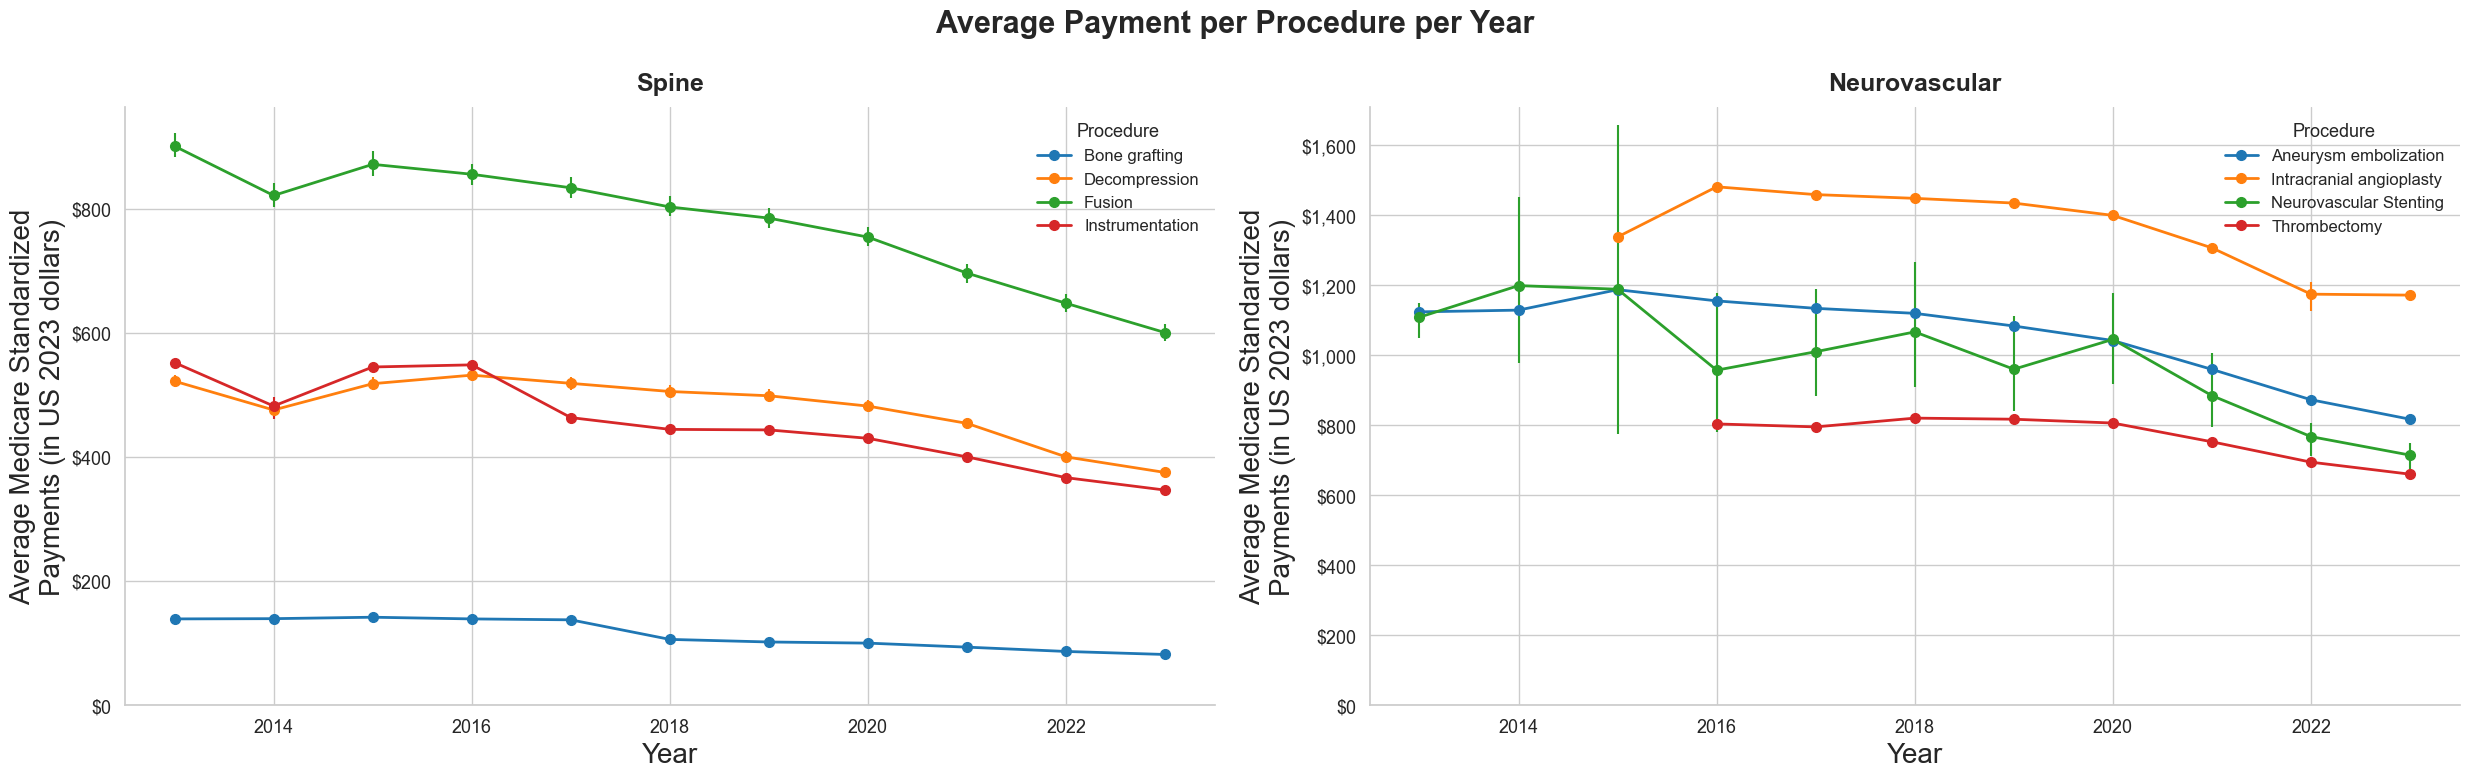

In [83]:
# Usage
plot_by_specialty_with_ci(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    y_col='Agg_Price_per_service_adj',
    ci_lower_col='CI_lower_agg_price_adj',
    ci_upper_col='CI_upper_agg_price_adj',
    y_label="Average Medicare Standardized\nPayments (in US 2023 dollars)",
    title_prefix="Average Medicare Standardized Payment by Procedure Type",
    title="Average Payment per Procedure per Year",
    legend_label_col='procedure_human_readable'
)

# Total Payment

In [84]:
util_2023_2013_adj_spine['Sum_Pymt_adj'].sum(), util_2023_2013_adj_neurovasc['Sum_Pymt_adj'].sum()

(4240630132.2900677, 66147425.24464801)

In [85]:
spine_total_payment_2013 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2013]['Sum_Pymt_adj'].sum()
spine_total_payment_2023 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2023]['Sum_Pymt_adj'].sum()

(spine_total_payment_2023 - spine_total_payment_2013) / spine_total_payment_2013 * 100

-30.619043882876262

In [86]:
neurovasc_total_payment_2013 = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] == 2013]['Sum_Pymt_adj'].sum()
neurovasc_total_payment_2023 = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] == 2023]['Sum_Pymt_adj'].sum()

(neurovasc_total_payment_2023 - neurovasc_total_payment_2013) / neurovasc_total_payment_2013 * 100

299.3246456071993

In [87]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [88]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -4.173 | weighted AAGR: -3.187

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -6.2129
 1  decompression    -5.81505
 2  fusion           -1.62892
 3  instrumentation  -3.03476

Neurovascular | unweighted AAGR: 13.209 | weighted AAGR: 14.652

    procedure                   AAGR_%
--  ------------------------  --------
 0  aneurysm_embo             10.4189
 1  intracranial_angioplasty  13.6219
 2  stent                      9.24838
 3  thrombectomy              19.5454



In [89]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovascular'][0]['AAGR_%'])

Ttest_indResult(statistic=-6.7994635921099, pvalue=0.0004956035162004884)

In [90]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    cagrs[specialty_name[i]] = compute_cagr(
        df,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
        years=[2013, 2023]
    )

In [91]:
for specialty, cagr in cagrs.items():
    print(specialty)
    print(tabulate.tabulate(cagr, headers=cagr.columns))
    print()

Spine
    procedure          CAGR_pct    effective_start_year    effective_end_year
--  ---------------  ----------  ----------------------  --------------------
 0  bone_grafting      -6.78158                    2013                  2023
 1  decompression      -6.12759                    2013                  2023
 2  fusion             -1.95727                    2013                  2023
 3  instrumentation    -3.61                       2013                  2023

Neurovascular
    procedure                   CAGR_pct    effective_start_year    effective_end_year
--  ------------------------  ----------  ----------------------  --------------------
 0  aneurysm_embo                9.58336                    2013                  2023
 1  intracranial_angioplasty    -3.40543                    2015                  2023
 2  stent                        6.05649                    2013                  2023
 3  thrombectomy                15.5872                     2016            

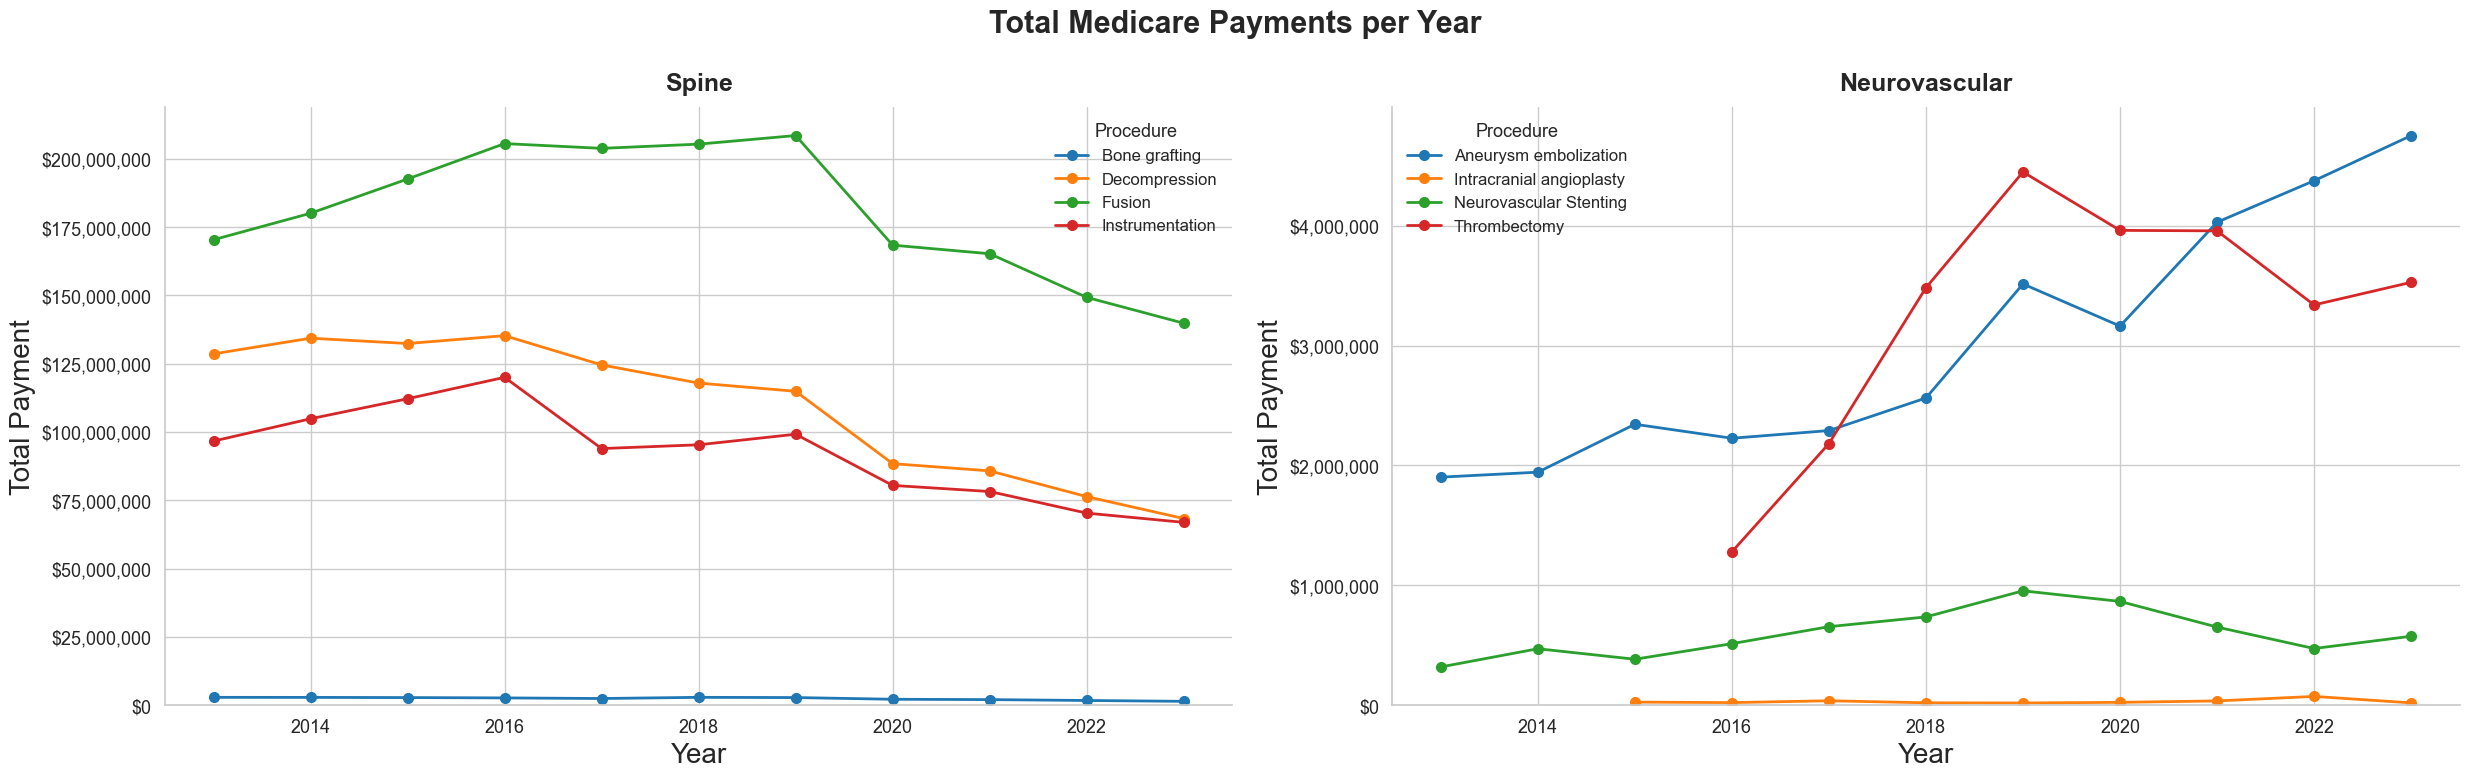

In [92]:
plot_by_specialty(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    y_col='Sum_Pymt_adj',
    y_label='Total Payment',
    figsize=(25, 8),
    format_as_dollar=True,
    title="Total Medicare Payments per Year",
    legend_label_col='procedure_human_readable'
)

# Total Payment Growth Rate

In [93]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [94]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -4.173 | weighted AAGR: -3.187

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -6.2129
 1  decompression    -5.81505
 2  fusion           -1.62892
 3  instrumentation  -3.03476

Neurovascular | unweighted AAGR: 13.209 | weighted AAGR: 14.652

    procedure                   AAGR_%
--  ------------------------  --------
 0  aneurysm_embo             10.4189
 1  intracranial_angioplasty  13.6219
 2  stent                      9.24838
 3  thrombectomy              19.5454



In [95]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovascular'][0]['AAGR_%'])

Ttest_indResult(statistic=-6.7994635921099, pvalue=0.0004956035162004884)

# Linear Regression by Change $ in Total Payment

In [104]:
# Usage
aagr_df_spine, aagr_df_neurovasc = compute_annual_change(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    col='Sum_Pymt_adj',
    change_col_name='sum_pymt_change',
    start_year=2017,
    end_year=2023
)

In [105]:
x_variables = ['Sum_Utilization', 'Avg_Price_per_service_adj']

In [106]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'sum_pymt_change'] + x_variables]
spine_data_for_regression['specialty'] = 0

neurovasc_data_for_regression = aagr_df_neurovasc[['procedure', 'year', 'sum_pymt_change'] + x_variables]
neurovasc_data_for_regression['specialty'] = 1

all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True).fillna(0)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_44003/793145289.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_44003/793145289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [107]:
X = all_regression_data.drop(columns=['sum_pymt_change', 'procedure']).dropna(subset=x_variables).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_pymt_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_pymt_change   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     4.121
Date:                Wed, 26 Aug 2026   Prob (F-statistic):            0.00572
Time:                        10:47:06   Log-Likelihood:                -956.47
No. Observations:                  56   AIC:                             1923.
Df Residuals:                      51   BIC:                             1933.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

# Linear Regression by Change Sum Utilization

In [100]:
# Usage
aagr_df_spine, aagr_df_neurovasc = compute_annual_change(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    col='Sum_Utilization',
    change_col_name='sum_util_change',
    start_year=2017,
    end_year=2023
)

In [101]:
x_variables = ['Avg_Price_per_service_adj']

In [102]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'sum_util_change'] + x_variables]
spine_data_for_regression['specialty'] = 0

neurovasc_data_for_regression = aagr_df_neurovasc[['procedure', 'year', 'sum_util_change'] + x_variables]
neurovasc_data_for_regression['specialty'] = 1

all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True).fillna(0)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_44003/1916421907.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_44003/1916421907.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [103]:
X = all_regression_data.drop(columns=['sum_util_change', 'procedure']).dropna(subset=x_variables).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_util_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_util_change   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.6701
Date:                Wed, 26 Aug 2026   Prob (F-statistic):              0.574
Time:                        10:46:48   Log-Likelihood:                -599.24
No. Observations:                  56   AIC:                             1206.
Df Residuals:                      52   BIC:                             1215.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 